## Project Card:

### The paper:
Sago et al. (2018): High-throughput in vivo screen of functional mRNA
delivery identifies nanoparticles for endothelial cell
gene editing. https://www.pnas.org/doi/pdf/10.1073/pnas.1811276115

### The data object:
Three points from Fig. 1G of the paper: the percentage of RFP+ cells after delivery of Cre mRNA with lipid nanoparticle L2K using 3 different doses of mRNA. The 3 different doses used were 10, 100, and 1000 ng, and they returned percentages of 4, 14, and 87%, respectively. These numbers were visually estimated from the heights of the bars, as there was no data table provided in the paper.

### The random variable chosen:
Z = the number of functional Cre mRNA copies that reach the nucleus of one cell. Z is not measured directly in our model. Instead, the measurement is the binary outcome RFP+ (Z ≥ 1) or RFP- (Z = 0). What is reported is the fraction of cells that are RFP+.

### What the paper does:
The paper details a system (FIND) that is able to screen many lipid nanoparticles at once and report functional mRNA delivery. The system uses barcoding to identify the specific nanoparticles and a Cre-Lox reporter system in which successful Cre mRNA delivery leads to a cell fluorescing red (RFP+ in cell lines, later tdTomato+ in mice). Using this system, the researchers then formulated and screened >250 LNPs, and identified the two most efficient ones (7C2 and 7C3). The efficiency and biodistribution of these compounds in different tissues, as well as their ability to codeliver Cas9 mRNA and sgRNA in vivo for gene editing, were later studied and compared in the paper.

Fig. 1G is the dose-response control the researchers used to optimize the mRNA dose for screening. The researchers wanted to find a dose range that was high enough that a large proportion of cells were RFP+, but not high enough that the system becomes "saturated". The paper discusses this saturation briefly but does not model it.

### The generative model proposed:
We propose that this saturation happens because each cell either gets at least one working mRNA copy or it doesn't. If a cell gets at least one copy, it turns red (RFP+). If it gets zero copies, it stays dark. At low doses, most cells get zero copies by chance, leading to a low % RFP+. As dose rises, each cell's odds of getting at least one copy climbs quickly at first, then plateaus towards a high probability.

We use the Poisson model to describe the number of copies of functional Cre mRNA a cell gets (Z), where the mean ($\lambda$) is proportional to dose, and one copy is enough to switch the cell to RFP+.


$$Z \sim \mathrm{Poisson}(\lambda), \qquad \lambda = kD, \qquad \text{RFP+} \iff Z \ge 1$$

$$P(\text{RFP+} \mid D, k) = 1 - P(Z = 0) = 1 - e^{-kD}$$

### Parameters and assumptions:

**Independent variable:**
| input | units | what it is | what a change does |
|---|---|---|---|
| D | ng | dose administered (the controlled input, not fitted) | larger D raises λ and so raises P(RFP+) toward 1 |

**Parameters:**
| parameter | units | what it is | what a change does |
|---|---|---|---|
| k | per ng | functional delivery rate: expected functional copies per cell per ng of dose | inversely proportional to dose, so a larger k (higher functional delivery rate) means a smaller dose is needed to reach the same fraction of RFP+. |

**Assumptions:**
1. A single functional copy of Cre mRNA is enough to produce the RFP+ outcome. A cell taking up additional functional copies does not change the outcome.
2. The expected number of copies per cell ($\lambda$) scales linearly with dose. 
3. All cells are identical and independent. One k applies to every cell, and one cell's uptake does not affect another's.
4. k is constant across the three doses, as the same delivery vehicle (L2K) is used for each dose (in this specific experiment we are trying to model - later in the paper the researchers describe different LNPs and thus varying k values would be more appropriate.)
5. The measurement is perfect - every cell with Z ≥ 1 is scored RFP+, and no cell is scored RFP+ by accident.

### The forward simulation:
For a given (test) k and dose, draw one uniform number [0, 1) per cell from a linear congruential generator. Score the cell RFP− if the draw falls below e^(−λ), RFP+ otherwise. 10,000 cells per run. The simulated fraction is checked against the direct implementation of 1 − e^(−kD).

### The parameterization/fitting:
A sweep of 351 candidate k values over 0.001–0.0045 per ng (step size = 0.00001) was performed. This range was calculated by rearranging the model to solve for k at each dose separately, and then bracketing roughly 0.0005 ng outside the minimum and maximum of these 3 points.

The candidates were scored by sum of squared error (SSE) against the three observed fractions. SSE was used rather than a likelihood because the paper does not publish the cell counts a binomial likelihood would need.

Result: k̂ = 0.00191 per ng.

### What/if the model adds to the paper:
The model gives a functional delivery rate (k) of about 0.00191 copies per cell per ng for L2K. This k value can be used to calculate the dose needed for any target RFP+ fraction. Realistically, this model adds little to the paper's conclusions. The dose-response figure itself is used as a calibration curve, and knowing k itself is not of much interest for the rest of the study.

### Model limitations/how it breaks:
The biggest limitation for the model is that one constant k is fit to all cells and all doses, which is not accurate. Across doses, it is apparent that k is not constant - the 10 ng point alone implies k ≈ 0.0041 per ng while the 100 ng point implies k ≈ 0.0015. Effects such as saturation of endocytosis receptors or toxicity at high doses that would make k non-constant are not modeled. Across cells, the assumption that each cell is identical and has identical uptake is weak. A mixture of rates would fit better at the cost of more parameters.

The single-hit assumption (that only one copy of Cre mRNA is needed to switch the cell to RFP+) breaks if several copies are needed for enough Cre to recombine both alleles.

Additionally, the paper briefly mentions the system as becoming "saturated" at values over 80% RFP+ (although it does not model this saturation or the minimum concentration at which it happens). Our model does not factor this in - as dose increases, the fraction of RFP+ will increase and plateau up to a ceiling of 100%.

Finally, the inputs are three bar heights read off a figure with no replicates and no counts, so the fitted interval below reflects reading error more than biological error.

In future work, given more data and replicates, many more parameters could be added to make k vary per cell, make k dose-dependent, make $\lambda$ saturate, and set a lower ceiling for %RFP+ saturation.




___
## Work:
### The data:

dose (ng):          [10.0, 100.0, 1000.0]
RFP+ (fraction):    [0.04, 0.14, 0.87]


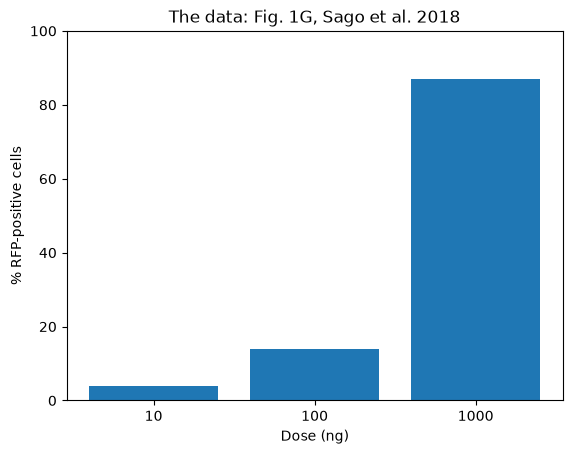

In [18]:
import csv
import math
import matplotlib.pyplot as plt

# The data, as estimated from Fig. 1G, Sago et al. 2018
dose = []
pct_RFP_pos = []
with open("data/dose_response.csv") as f:
    for row in csv.DictReader(f):
        dose.append(float(row["dose_ng"]))
        pct_RFP_pos.append(float(row["pct_rfp_pos"]))

observed_fractions = [p / 100 for p in pct_RFP_pos]
print("dose (ng):         ", dose)
print("RFP+ (fraction):   ", observed_fractions)

plt.bar([str(int(d)) for d in dose], pct_RFP_pos)
plt.xlabel("Dose (ng)")
plt.ylabel("% RFP-positive cells")
plt.ylim(0, 100)
plt.title("The data: Fig. 1G, Sago et al. 2018")
plt.show()

### The model:

 We model the number of copies a cell gets as a Poisson random variable - where each event (an mRNa copy ending up in a particular cell) is random,  independent across copies, and individually unlikely to occur.

 Z = number of mRNA copies a cell receives (our random variable)

 λ = k * dose (the average number of copies per cell, which depends on k (1/ng) and dose (ng)).
 
 Z ~ Poisson(λ)

 The measurement: a cell is RFP+ if Z >= 1.
 
 We can derive the measurement from the Poisson probability mass function:
 $$P(Z = n) = \frac{\lambda^n e^{-\lambda}}{n!}$$

 The probability for n = 0 (the cell receives Z = 0 copies, and thus the cell is RFP-):
 $$P(Z = 0) = \frac{\lambda^0 e^{-\lambda}}{0!}$$
 $$P(Z = 0) = \frac{1 e^{-\lambda}}{1}$$
 $$P(Z = 0) = e^{-\lambda}$$

 Then getting to P(RFP+):

 A cell is RFP+ if it receives at least one copy. Z >=1 is the complement of Z = 0, so:
 $$P(Z \ge 1) = 1 - P(Z = 0) = 1 - e^{-\lambda} = 1 - e^{-kD}$$


### Running it forwards (simulating):

To simulate the results, simulating a full Poisson count per cell is not necessary. Instead, we can just simulate whether a cell got zero copies (RFP-) or at least one (RFP+).

RFP- should happen with probability e^(−λ) (the Poisson chance of zero copies).

RFP+ should happen with probability 1 - e^(−λ).

To simulate this, we can draw one random number from the interval \[0, 1\), where every value in that range is equally likely. We then split that interval into two pieces, where each piece's length matches the probability of one outcome:

```
0              e^(-λ)                                  1
|-----------------|------------------------------------|
      RFP-        |                RFP+                 
  length = e^(-λ) |         length = 1 - e^(-λ)         
```

If a random number drawn, r, is less than e^(−λ), the cell is RFP-. Otherwise, the cell is RFP+.

In [19]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def p_model(k, dose):
    """Analytical probability that a cell is RFP+ at dose, for rate k."""
    """Takes k and the independent variable, dose and returns P(RFP+): 1 - e^(−λ) """
    return -math.expm1(-k * dose) # uses the negative of math.expm1 rather than 1 - math.exp to reduce computing errors that might arise with small lambda

def simulate(k, dose, n_cells=10000, seed=737):
    """Instead of simulating the actual Poisson counts, simulate the simplified version:
    either RFP-positive or RFP-negative based on a threshold."""
    probability_zero = math.exp(-k * dose)
    pos_count = 0
    draws = uniforms(n_cells, seed)
    for r in draws:
        if r >= probability_zero:
            pos_count += 1
    return pos_count / n_cells  # return the fraction of RFP+ cells

test_k = 0.0006
test_dose = 100

modeled = p_model(test_k, test_dose)
simulated = simulate(test_k, test_dose, n_cells = 10000, seed = 737)

# A small difference here implies that the simulate() function follows the model well
print("Using the test values:")
print(f"exact fraction from the model:          {modeled:.4f}")
print(f"simulated fraction from random draws:   {simulated:.4f}")
print(f"difference:                             {abs(modeled - simulated):.4f}")


Using the test values:
exact fraction from the model:          0.0582
simulated fraction from random draws:   0.0570
difference:                             0.0012


### Running it backwards (scoring):

We now see that the simulated values follow the model. However, the model does not perfectly fit the data - the fraction of RFP+ cells should be around 0.14 (14% RFP+) for a dose of 100 ng. Therefore, we must estimate the parameter k based off the paper's results.

The data are visual estimates of the bar heights in Fig. 1G of Sago et al.(2018), with doses of 10, 100, and 1000 ng resulting in 4, 14, and 87% RFP+, respectively.

First, we write a function to score a candidate k using the sum of squared errors (we can't use NLL here, as it would require cell counts):

In [20]:
def score(k, fractions):
    total = 0.0
    for i in range(len(dose)): # 3 doses: 10, 100, 1000 ng
        gap = p_model(k, dose[i]) - fractions[i]
        total += gap ** 2
    return total

Then, we create a range of candidates that k could be.

From the data, 
p(RFP+) = 1 − e^(−k·dose). We can solve for k and find:

1 - p(RFP+) = e^(−k·dose)

ln(1 - p) = -k * dose

→ k = −ln(1 − p) / dose

We can get a rough idea of k by inverting the model for each observed data point. 

When dose is 10, observed fraction = 0.04:  
k = -ln(1-0.04) / 10 ≈ 0.0041

When dose is 100, observed fraction = 0.14:    
k = −ln(1-0.14) / 100 ≈ 0.0015

When dose is 1000, observed fraction = 0.87:  
k = −ln(1-0.87) / 1000 ≈ 0.0020

We estimate that the most optimal k value will fall within a range of 0.001-0.0045.

In [21]:
M = 351
candidates = [0.0] * M
# a list of 351 candidates from 0.001-0.0045 with a step of 0.00001, without floating point rounding errors
for j in range(M): 
    candidates[j] = (100 + j) / 100000

scores = [0.0] * M
for j in range(M):
    scores[j] = score(candidates[j], observed_fractions)


The candidate k with the lowest score (k_hat) means that the model's curve is closer to the data. To find k_hat, find the position of the minimum score:

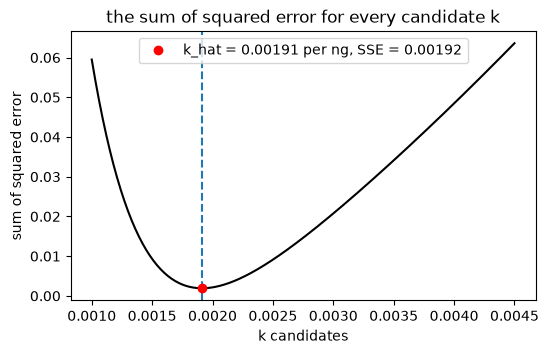

In [22]:
def position_of_min(values):
    """The index of the smallest entry"""
    best = 0
    for j in range(len(values)):
      if values[j] < values[best]:
        best = j
    return best

k_hat = candidates[position_of_min(scores)]
best_score = scores[position_of_min(scores)]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(candidates, scores, color="black")
ax.axvline(k_hat, ls="--")
ax.plot([k_hat], [best_score], "o", color="red", label=f"k_hat = {k_hat:.5f} per ng, SSE = {best_score:.5f}")
ax.set_xlabel("k candidates")
ax.set_ylabel("sum of squared error")
ax.set_title("the sum of squared error for every candidate k")
ax.legend()
plt.show()


The fitted k is 0.00191 per ng, with a sum of squared error of 0.00192.

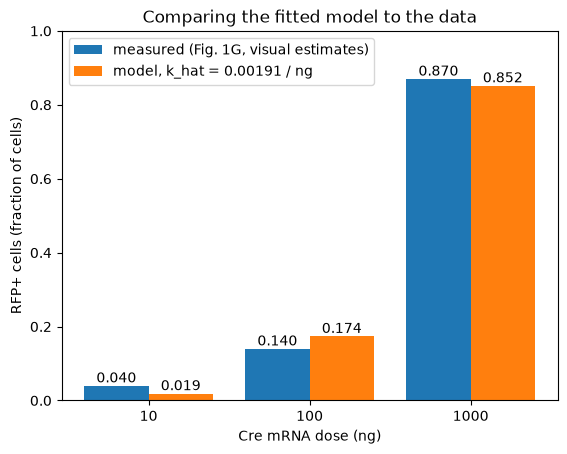

In [23]:
positions = [0, 1, 2]
obs_x = [0.0] * len(dose)
model_x = [0.0] * len(dose)
model_fractions = [0.0] * len(dose)
for i in range(len(dose)):
    obs_x[i] = positions[i] - 0.2            # measured bar sits left of the tick
    model_x[i] = positions[i] + 0.2          # model bar sits right of the tick
    model_fractions[i] = p_model(k_hat, dose[i]) # finding the estimates from the model with the fitted k

obs_bars = plt.bar(obs_x, observed_fractions, width=0.4, label="measured (Fig. 1G, visual estimates)")
model_bars = plt.bar(model_x, model_fractions, width=0.4, label=f"model, k_hat = {k_hat:.5f} / ng")
plt.bar_label(obs_bars, fmt="%.3f")          # value on top of each measured bar
plt.bar_label(model_bars, fmt="%.3f")        # value on top of each model bar
plt.xticks(positions, ["10", "100", "1000"])
plt.xlabel("Cre mRNA dose (ng)")
plt.ylabel("RFP+ cells (fraction of cells)")
plt.title("Comparing the fitted model to the data")
plt.ylim(0, 1)
plt.legend()
plt.show()

The bar comparison shows the fit at the three measured doses only, but using the k_hat, we can plot the model as a continuous curve as well, including the doses the paper did not test:

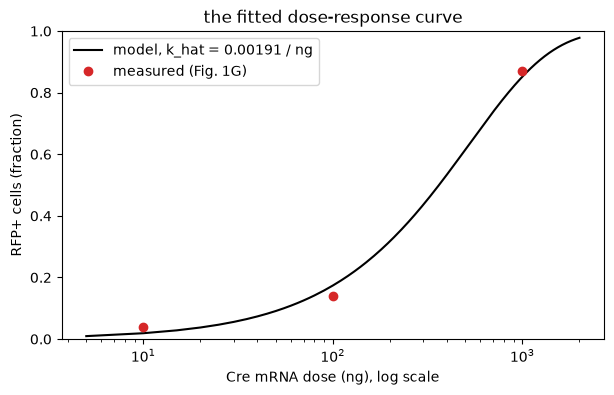

P(RFP+) at a dose of 0 ng:      0.0000   (expected 0)
P(RFP+) at a dose of 100000 ng: 1.0000   (expected 1)
dose for 50% RFP+:              363 ng
dose for 95% RFP+:              1568 ng


In [24]:
# the model's prediction across a continuous dose range
curve_dose = [0.0] * 400
curve_p = [0.0] * 400
for i in range(400):
    curve_dose[i] = 5 + i * 5                    # 5 ng up to 2000 ng
    curve_p[i] = p_model(k_hat, curve_dose[i])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve_dose, curve_p, color="black", label=f"model, k_hat = {k_hat:.5f} / ng")
ax.plot(dose, observed_fractions, "o", color="tab:red", label="measured (Fig. 1G)")
ax.set_xscale("log")
ax.set_xlabel("Cre mRNA dose (ng), log scale")
ax.set_ylabel("RFP+ cells (fraction)")
ax.set_ylim(0, 1)
ax.set_title("the fitted dose-response curve")
ax.legend()
plt.show()

# sanity checks: known conditions should line up with expectations
print(f"P(RFP+) at a dose of 0 ng:      {p_model(k_hat, 0):.4f}   (expected 0)")
print(f"P(RFP+) at a dose of 100000 ng: {p_model(k_hat, 100000):.4f}   (expected 1)")
print(f"dose for 50% RFP+:              {math.log(2) / k_hat:.0f} ng")
print(f"dose for 95% RFP+:              {-math.log(0.05) / k_hat:.0f} ng")

### Uncertainty:
The sweep gave one best value of $k$, but the three fractions it was fitted to are visual estimates of bar heights, not published numbers. To see how much $\hat{k}$ depends on that reading, we shift each observed fraction by a random amount drawn uniformly from ±0.03 and refit, 300 times. The ±0.03 is an assumption: it stands in for how precisely a bar height can be read off the published figure. The spread of the refitted values shows how sensitive the estimate is to that reading error. 300 repeats was enough for the interval to stabilise without excessive computation.

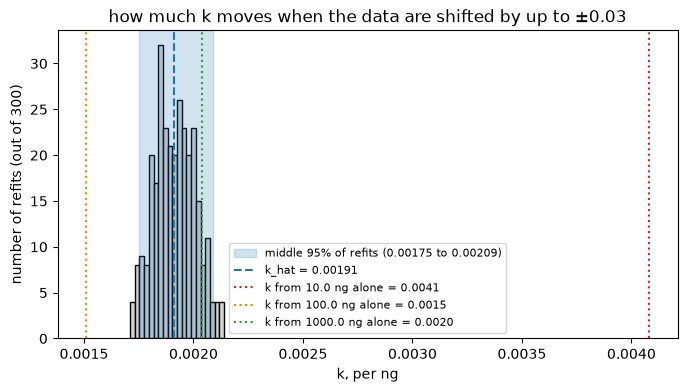

In [25]:
def fit_k(fractions):
    """Run the same sweep as before, on any list of fractions."""
    scores_i = [0.0] * M
    for j in range(M):
        scores_i[j] = score(candidates[j], fractions)
    return candidates[position_of_min(scores_i)]

n_repeats = 300
error = 0.03
draws = uniforms(n_repeats * 3, 737) # creates a list corresponding to one random number per dose per repeat

k_values = [0.0] * n_repeats
for r in range(n_repeats):
    shifted = [0.0] * len(dose)
    for i in range(len(dose)):
        # shifts each dose's "observed fraction" by a random number between -0.03 and +0.03
        shifted[i] = observed_fractions[i] + error * (2 * draws[3 * r + i] - 1)
    k_values[r] = fit_k(shifted) # runs the sweep on the altered data, stores the best k in position r

# finds the range that holds the middle 95% of the 300 repeats (cutting out 2.5% of the most extreme values on either side)
k_sorted = sorted(k_values)
low = k_sorted[int(0.025 * n_repeats)]
high = k_sorted[int(0.975 * n_repeats) - 1]

# the k each dose gives on its own
k_each = [0.0] * len(dose)
for i in range(len(dose)):
    k_each[i] = -math.log(1 - observed_fractions[i]) / dose[i]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(k_values, bins=20, color="lightgray", edgecolor="black")
ax.axvspan(low, high, color="tab:blue", alpha=0.2, label=f"middle 95% of refits ({low:.5f} to {high:.5f})")
ax.axvline(k_hat, color="tab:blue", ls="--", label=f"k_hat = {k_hat:.5f}")
colors = ["tab:red", "tab:orange", "tab:green"]
for i in range(len(dose)):
    ax.axvline(k_each[i], color=colors[i], ls=":", label=f"k from {dose[i]} ng alone = {k_each[i]:.4f}")
ax.set_xlabel("k, per ng")
ax.set_ylabel(f"number of refits (out of {n_repeats})")
ax.set_title(f"how much k moves when the data are shifted by up to ±{error}")
ax.legend(fontsize=8)
plt.show()

The middle 95% of refits spans from 0.00175 to 0.00209, so $\hat{k}$ is stable against a few percent of reading error. However, the orange and red dotted lines (the values each dose implies on its own) sit well outside the k interval. The green band is within the interval but not a likely estimate.

The spread between doses is therefore much larger than the spread from reading error. This actually points to a failure of the model itself rather than a failure of the fitting procedure.

### Conclusion/Validity:

The model does what it was proposed to do: it explains the shape of the dose response from a mechanism rather than by fitting a curve. The flattening arises from the fact that a cell can only be counted once, so the expected number of copies keeps rising with dose while the measured probability of receiving at least one is bounded by one.

At the fitted $\hat{k}$, the model gives 0.019, 0.174, and 0.852 against the measured 0.04, 0.14, 0.87. On an absolute scale, these modeled values are fairly close (although at the 10 ng point, this is a two-fold difference). The overall shape of the response fits well. 

However, the model is rejected by its own consistency check. A single, non-dose-dependent $k$ should give the same value at every dose, and it does not. The three doses gave 0.0041, 0.0015 and 0.0020 per ng, a spread that was found to be far wider than the uncertainty from reading the figure. One rate cannot describe all three points, and the fitted $\hat{k} = 0.00191$ per ng should be read as a population- and dose-averaged number rather than a property of L2K.

The failure is still informative. The varying k points at either cell-to-cell variation in uptake or a dose-dependent delivery rate. These could be included in subsequent attempts at modelling, although neither can be tested without a larger, more informative dataset (more doses, more replicates, clear cell counts) than the paper reports.